#### Fig 1. Carbon intensity, water scarcity index, and HPC power consumption of mainland US.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import geopandas as gpd
import pandas as pd
plt.rcParams.update({'mathtext.default':  'regular' })
plt.rcParams["font.family"] = "serif"
fontsize=12

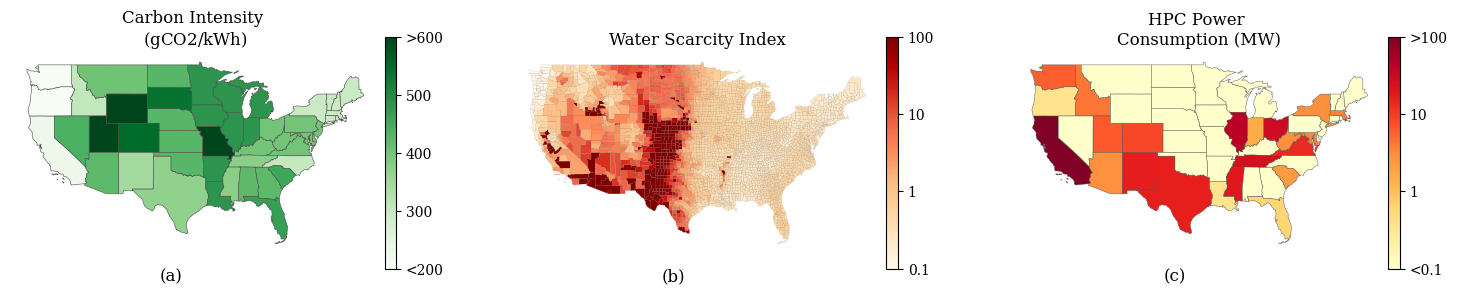

In [2]:
fig, axs = plt.subplots(nrows=1, ncols=3,
                         gridspec_kw={'hspace': -0.1, 'wspace': 0.3, 'bottom': 0.2,
                                      'top': 0.8, 'right': 0.995, 'left': 0.3},
                         figsize=(20, 9),
                         sharey=True)

# US state carbon intensity
states = gpd.read_file("../cb_2024_us_state_20m.zip")
states = states[~states['STUSPS'].isin(['HI', 'AK', 'PR'])]
states['STATEFP'] = states['STATEFP'].astype(str).str.zfill(2)
df = pd.read_csv("../US_county_state_dataset/US_state_carbon_intensity.csv")
df['state_fips'] = df['state_fips'].astype(str).str.zfill(2)
gdf = states.merge(df, left_on='STATEFP', right_on='state_fips', how='left')
vmin, vmax = 200,600
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.Greens
tick_vals = [200, 300, 400,500, 600]
tick_labels = ['<200', '300', '400', '500','>600']
gdf.plot(
    column='CI',
    cmap=cmap,
    norm=norm,
    linewidth=0.4,
    ax=axs[0],
    edgecolor='0.3',
    legend=False
)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm._A = []
cbar = fig.colorbar(sm, ax=axs[0], fraction=0.03, pad=0.01,ticks=tick_vals)
cbar.ax.minorticks_off() 
cbar.ax.set_yticklabels(tick_labels)
axs[0].set_title("Carbon Intensity \n(gCO$2$/kWh)", fontsize=12)
axs[0].set_axis_off()



#County level water scarcity index
counties = gpd.read_file("../cb_2021_us_county_20m.zip")
df = pd.read_csv("../US_county_state_dataset/US_county_water_scarcity_index.csv")
df['FIPS'] = df['FIPS'].astype(str).str.zfill(5)  
counties['GEOID'] = counties['GEOID'].astype(str).str.zfill(2)
gdf = counties.merge(df, left_on='GEOID', right_on='FIPS')
gdf = gdf[~gdf['STATEFP'].isin(['02', '15', '72'])]  # AK=02, HI=15, PR=72
vmin, vmax = 0.1, 100
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
cmap = plt.cm.OrRd

tick_vals = [0.1, 1, 10, 100]
tick_labels = ['0.1', '1', '10', '100']
gdf.plot(
    column='WSI',
    cmap=cmap,
    norm=norm,
    linewidth=0.05,
    ax=axs[1],
    edgecolor='0.2',
    legend=False
)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm._A = []

cbar = fig.colorbar(sm, ax=axs[1], fraction=0.03, pad=0.01, ticks=tick_vals)
cbar.ax.minorticks_off()
cbar.ax.set_yticklabels(tick_labels)

axs[1].set_title("Water Scarcity Index", fontsize=12)
axs[1].set_axis_off()



states = gpd.read_file("../cb_2024_us_state_20m.zip")
states = states[~states['STUSPS'].isin(['HI', 'AK', 'PR'])]
df = pd.read_csv("../US_county_state_dataset/US_county_HPC_power.csv")
df['FIPS'] = df['geoid'].astype(str).str.zfill(5)
df['STATEFP'] = df['FIPS'].str[:2]
state_power = df.groupby('STATEFP', as_index=False)['total_power_kw'].sum()
state_power.columns = ['STATEFP', 'total_power_kw']
states['STATEFP'] = states['STATEFP'].astype(str).str.zfill(2)
gdf = states.merge(state_power, on='STATEFP', how='left')
gdf['total_power_kw'] = gdf['total_power_kw'].fillna(100)
vmin, vmax = 100, 100000
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
cmap = plt.cm.YlOrRd
tick_vals = [100, 1000, 10000, 100000]
tick_labels = ['<0.1', '1', '10', '>100']
gdf.plot(
    column='total_power_kw',
    cmap=cmap,
    norm=norm,
    linewidth=0.3,
    ax=axs[2],
    legend=False,  # Disable automatic legend so we can control the colorbar.
    edgecolor='0.3'
)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm._A = [] 
cbar = fig.colorbar(sm, ax=axs[2], fraction=0.03, pad=0.01, ticks=tick_vals)
cbar.ax.minorticks_off() 
cbar.ax.set_yticklabels(tick_labels)
axs[2].set_title("HPC Power \nConsumption (MW)", fontsize=12)
axs[2].set_axis_off()
axs[0].text(-100, 20, "(a)", fontsize=fontsize, ha='center', va='center', rotation=0)
axs[1].text(-100, 20, "(b)", fontsize=fontsize, ha='center', va='center', rotation=0)
axs[2].text(-100, 20, "(c)", fontsize=fontsize, ha='center', va='center', rotation=0)
plt.savefig("../figures/figure1.pdf",  bbox_inches='tight')


